# Neural Networks

## Setting Up

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import csv
import time

In [2]:
data_set = np.matrix(pd.read_csv("data.csv", header=None))
labels = np.array(pd.read_csv("data_labels.csv", header=None))
test_set = np.matrix(pd.read_csv("test_set.csv", header=None))
data_set.shape

(3486, 354)

## Blueprint for Brain or NN

In [3]:
n_in = data_set.shape[1] # input neurons (cols)
# n_h1 = data_set.shape[1] # hidden neurons (same size as input)
# a. Make the number of neurons of the first hidden layer twice the size of the input layer 
n_h1 = data_set.shape[1] * 2
n_h2 = data_set.shape[1]
n_out = 8 # output neurons (8 categories ; highest number will be the correct one)
eta = 0.1 # learning rate

## Initialization Phase

In [4]:
x_in = np.zeros((n_in, 1)) # one row of data
# randomize weights
w_h1 = np.random.uniform(low=-0.1, high=0.1, size=(n_h1, n_in))*0.1 # weights input to hidden 1
b_h1 = np.random.uniform(low=-0.1, high=0.1, size=(n_h1, 1))*0.1 # bias input to hidden 1

# b. Remove the 2nd hidden layer (it means that only 1 hidden layer is between the input and the output layer 

# w_h2 = np.random.uniform(low=-0.1, high=0.1, size=(n_h2, n_h1))*0.1 # weights hidden 1 to hidden 2
# b_h2 = np.random.uniform(low=-0.1, high=0.1, size=(n_h2, 1))*0.1 # bias hidden 1 to hidden 2
# w_out = np.random.uniform(low=-0.1, high=0.1, size=(n_out, n_h2))*0.1 # weights hidden 2 to output
# b_out = np.random.uniform(low=-0.1, high=0.1, size=(n_out, 1))*0.1 # bias hidden 2 to output

w_out = np.random.uniform(low=-0.1, high=0.1, size=(n_out, n_h1))*0.1 # weights hidden 1 to output
b_out = np.random.uniform(low=-0.1, high=0.1, size=(n_out, 1))*0.1 # bias hidden 1 to output
d_out = np.zeros((n_out, 1)) # desired output

## One-Hot Encoding
Row of classes (8 categories) to set equal importance to category numbers
- 1 = on
- This is used to calculate the error by comparing the 8 numbers against the perfect answer

In [5]:
Y = np.matrix([[1, 0, 0, 0, 0, 0, 0, 0],
               [0, 1, 0, 0, 0, 0, 0, 0],
               [0, 0, 1, 0, 0, 0, 0, 0],
               [0, 0, 0, 1, 0, 0, 0, 0],
               [0, 0, 0, 0, 1, 0, 0, 0],
               [0, 0, 0, 0, 0, 1, 0, 0],
               [0, 0, 0, 0, 0, 0, 1, 0],
               [0, 0, 0, 0, 0, 0, 0, 1]])

## Utility Tools
math, measurement, visualization

In [6]:
# Calculate grade of model
def getAccuracy(correct, overall_data):
    accuracy = (correct / overall_data) * 100
    print("Correct predictions: ", correct)
    print("Accuracy: ", accuracy)

# Show how total error drops after each round
def plot(figure):
    plt.figure()
    plt.plot(figure)
    plt.show()

# Activator (Logistic function) used in forward propagation to make a guess
# Input (any number), Output (Between 0 and 1)
def sigmoid(vector):
    return 1 / (1 + np.exp(-vector))

# Gradient (slope) of the sigmoid curve is used in backpropagation fix weights
def sigmoidPrime(sigmoid):
    return np.multiply(sigmoid,(1-sigmoid))

## Stochastic Gradient Descent : Training
Training Loop where model learns from data

In [7]:
# Go through entire dataset 1000 times
# Goal is to get error smaller with each pass
max_epoch = 1000 
total_err = np.zeros((max_epoch, 1))

# Ensure all data are numpy arrays
data_set = np.array(data_set)
Y = np.array(Y)
labels = np.array(labels)

for epoch in range(max_epoch):
    epoch_error = 0  # accumulate squared error
    
    for idx, row in enumerate(data_set[:3001]):
        # --- Prepare input and target as column vectors ---
        x_in = row.reshape(-1, 1)          # shape: (n_in,1)
        d_out = Y[labels[idx]-1].reshape(-1,1)  # shape: (n_out,1)
        
        # --- Forward propagation ---
        # Make a guess by passing data through layers and get output
        
        # Hidden layer 1
        # Multiply input by weights -> add bias -> apply sigmoid
        v_h1 = np.dot(w_h1, x_in) + b_h1     # (n_h1,1)
        y_h1 = sigmoid(v_h1)                 # (n_h1,1)

        # b. Remove the 2nd hidden layer (it means that only 1 hidden layer is between the input and the output layer 
        
        # Hidden layer 2
        # v_h2 = np.dot(w_h2, y_h1) + b_h2     # (n_h2,1)
        # y_h2 = sigmoid(v_h2)                 # (n_h2,1)
        
        # # Output layer
        # v_out = np.dot(w_out, y_h2) + b_out  # (n_out,1)
        # out = sigmoid(v_out)                 # (n_out,1)

        # Output layer
        v_out = np.dot(w_out, y_h1) + b_out  # (n_out,1)
        out = sigmoid(v_out)                 # (n_out,1)
        
        
        # --- Compute error ---
        # Compare guess vs ground truth from the one-hot encoded matrix
        err = out - d_out
        # epoch_error += np.sum(err**2)
        
        # --- Backpropagation ---
        # Find the errors from output to input
        # Delta: how much was this layer responsible for the final mistake
        
        # Output layer delta
        delta_out = err * sigmoidPrime(out)                 # (n_out,1)

        # b. Remove the 2nd hidden layer (it means that only 1 hidden layer is between the input and the output layer 
        
        # Hidden layer 2 delta
        # delta_h2 = np.dot(w_out.T, delta_out) * sigmoidPrime(y_h2)  # (n_h2,1)
        
        # Hidden layer 1 delta
        # delta_h1 = np.dot(w_h2.T, delta_h2) * sigmoidPrime(y_h1)   # (n_h1,1)

        # Hidden layer 1 delta
        delta_h1 = np.dot(w_out.T, delta_out) * sigmoidPrime(y_h1)   # (n_h1,1)
        
        # --- Update weights and biases ---
        # Learning happens here by taking current weights and subtracting a small amount
        # controlled by eta or learning rate

        # b. Remove the 2nd hidden layer (it means that only 1 hidden layer is between the input and the output layer
        
        # w_out = w_out - eta * np.dot(delta_out, y_h2.T)   # (n_out, n_h2)
        # b_out = b_out - eta * delta_out                   # (n_out,1)

        w_out = w_out - eta * np.dot(delta_out, y_h1.T)   # (n_out, n_h1)
        b_out = b_out - eta * delta_out  
        
        # w_h2 = w_h2 - eta * np.dot(delta_h2, y_h1.T)     # (n_h2, n_h1)
        # b_h2 = b_h2 - eta * delta_h2                     # (n_h2,1)
        
        # w_h1 = w_h1 - eta * np.dot(delta_h1, x_in.T)     # (n_h1, n_in)
        # b_h1 = b_h1 - eta * delta_h1                     # (n_h1,1)

        w_h1 = w_h1 - eta * np.dot(delta_h1, x_in.T)     # (n_h1, n_in)
        b_h1 = b_h1 - eta * delta_h1                     # (n_h1,1)
    
    # --- Record total error for this epoch ---
    total_err[epoch] = total_err[epoch] + np.sum(err**2)
    # total_err[epoch] = epoch_error
    print(f'Epoch {epoch+1}, Error: {total_err[epoch][0]}')
    
    # --- Termination condition ---
    if total_err[epoch] < 0.001:
        print("Training converged.")
        break

Epoch 1, Error: 0.0549716083777533
Epoch 2, Error: 0.05337936294353077
Epoch 3, Error: 0.036217034803836375
Epoch 4, Error: 0.035378277428600474
Epoch 5, Error: 0.03903422054521198
Epoch 6, Error: 0.040678015685317315
Epoch 7, Error: 0.04101259834751811
Epoch 8, Error: 0.04089953579830325
Epoch 9, Error: 0.040700527143483003
Epoch 10, Error: 0.04066926857902973
Epoch 11, Error: 0.040913817388690495
Epoch 12, Error: 0.041298892776476914
Epoch 13, Error: 0.04116170500644911
Epoch 14, Error: 0.04024962042334715
Epoch 15, Error: 0.03970553859634867
Epoch 16, Error: 0.03970026133182112
Epoch 17, Error: 0.03995784276373435
Epoch 18, Error: 0.040255056370942593
Epoch 19, Error: 0.040441729972087746
Epoch 20, Error: 0.04045225912914104
Epoch 21, Error: 0.04029946745890607
Epoch 22, Error: 0.040049331486669615
Epoch 23, Error: 0.03977883630615726
Epoch 24, Error: 0.03952729364213818
Epoch 25, Error: 0.03928017993294384
Epoch 26, Error: 0.03905350508678486
Epoch 27, Error: 0.03889573899924249
Ep

## Val Phase
Same as training except no backpropagation and weight training
- Use the learned weights to predict
- Check for accuracy

In [8]:
# Validation phase
labels_test = labels[3001:]
correct = 0

for idx, row in enumerate(data_set[3001:]):
    x_in = row.reshape(-1, 1)  # column vector (n_in,1)

    # Hidden layer 1
    v_h1 = np.dot(w_h1, x_in) + b_h1
    y_h1 = sigmoid(v_h1)

    # b. Remove the 2nd hidden layer (it means that only 1 hidden layer is between the input and the output layer
    
    # Hidden layer 2
    # v_h2 = np.dot(w_h2, y_h1) + b_h2
    # y_h2 = sigmoid(v_h2)
    
    # Output layer
    # v_out = np.dot(w_out, y_h2) + b_out
    # out = sigmoid(v_out)

    v_out = np.dot(w_out, y_h1) + b_out
    out = sigmoid(v_out)
    
    # --- Prediction ---
    # Convert output column vector to 1D array and get index of max
    # Find the highest number in the list; this is the final answer
    yy = np.argmax(out.flatten()) + 1  # +1 if labels are 1-indexed
    
    # Check if prediction matches label
    if yy == labels_test[idx]:
        correct += 1

# --- Accuracy ---
accuracy = correct / len(labels_test)
print(f'Validation Accuracy: {accuracy*100:.2f}%')

Validation Accuracy: 93.61%


## Test Phase
Generate actual results on data with no labels yet

In [9]:
# --- Test Phase ---
test_results = [] # Final guess

for row in test_set:
    x_in = row.reshape(-1, 1)  # (n_in,1)
    
    # --- Forward propagation ---
    # Prev layer results -> weights -> sigmoid
    
    # Hidden layer 1
    v_h1 = np.dot(w_h1, x_in) + b_h1
    y_h1 = sigmoid(v_h1)

    # b. Remove the 2nd hidden layer (it means that only 1 hidden layer is between the input and the output layer
    
    # Hidden layer 2
    # v_h2 = np.dot(w_h2, y_h1) + b_h2
    # y_h2 = sigmoid(v_h2)
    
    # # Output layer
    # v_out = np.dot(w_out, y_h2) + b_out
    # out = sigmoid(v_out)

    v_out = np.dot(w_out, y_h1) + b_out
    out = sigmoid(v_out)

    # --- Prediction ---
    # pick the highest one from the output
    yy = np.argmax(out.flatten()) + 1  # +1 if labels are 1-indexed
    test_results.append(str(yy))

Correct predictions:  454
Accuracy:  93.6082474226804


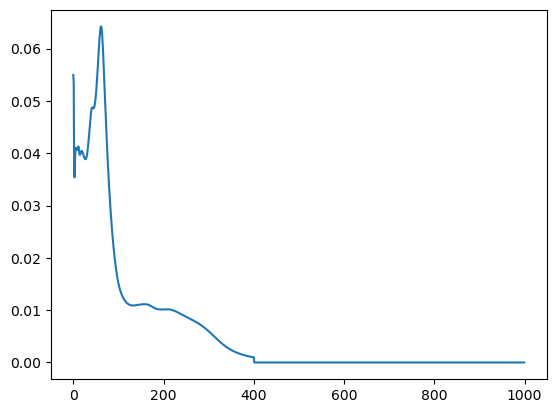

In [10]:
getAccuracy(correct, len(data_set[3001:]))
plot(total_err)

<h2>Your Assignment</h2>

Tweak the neural network and do the following:

a. Make the number of neurons of the first hidden layer twice the size of the input layer <br>
b. Remove the 2nd hidden layer (it means that only 1 hidden layer is between the input and the output layer <br>
c. Run the neural network <br>
d. Observe the accuracy - did the results improve or worsen?<br>
e. Submit a jupyter notebook in LMS (Deadline will be on March 31)

### Original Code

Epoch 367, Error: 0.001002142300409884

Epoch 368, Error: 0.0009945140267290551

Training converged.

Validation Accuracy: 89.69%

Correct predictions:  435

Accuracy:  89.69072164948454

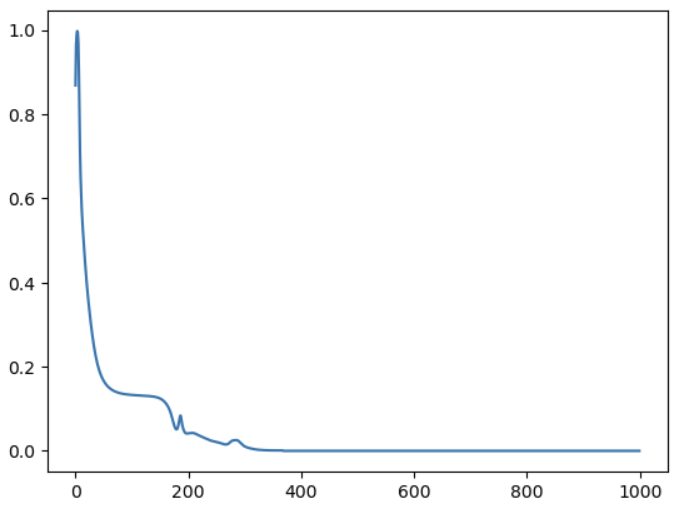

### Modified Code

Epoch 400, Error: 0.0010049759024786365

Epoch 401, Error: 0.0009969334722640937

Training converged.

Validation Accuracy: 93.61%

Correct predictions:  454

Accuracy:  93.6082474226804
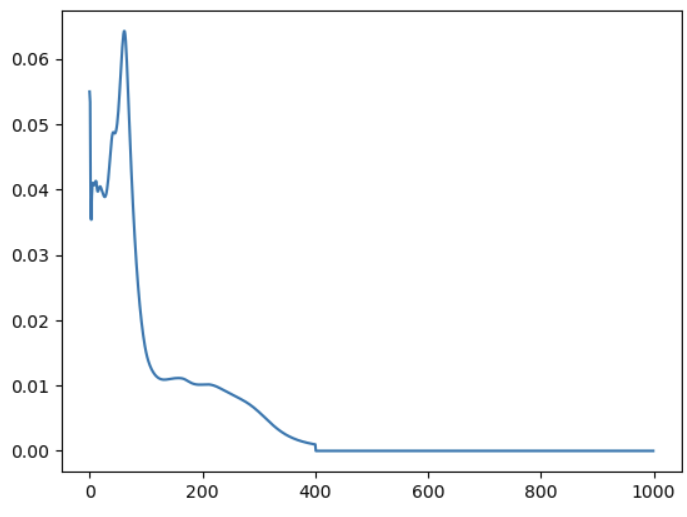

The original model, which used two hidden layers of 354 neurons each, resulting in a good performance already with an accuracy of 89.69%. However, after doubling the first hidden layer to 708 neurons and removing the second layer, the accuracy climbed to 93.61% — a 3.92% improvement.

This shift most likely happened because the larger first layer caught more features than having two smaller layers since the first layer is responsible for feature extraction and doubling the neurons increased the model's vocabulary to describe the input. By removing the second layer, the connection between the input and output was simplified. When there are too many layers, the learning signals get weaker as they travel back through them or what is called the vanishing gradient problem, which would explain why removing the second layer enabled the error signals to push through normally. In this case, a single larger layer proved to be more efficient at mapping the data to each of the categories.